In [23]:
import pandas as pd

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [24]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [25]:
def get_recalls_auc(path: Path):
    experiments: list[list] = load_experiment_metrics(path)
    recalls_auc: list[float] = []
    for experiment in experiments:
        recall_auc = AbstractContextualModel.calculate_partial_auc(experiment)
        recalls_auc.append(recall_auc)

    return recalls_auc

In [34]:
latent_transform_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "latent_transform_v3"
baseline_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline_v2"

In [27]:
latent_transform_recalls, latent_transform_precisions = get_precisions_recalls(latent_transform_path)
baseline_recalls, baseline_precisions = get_precisions_recalls(baseline_path)

In [28]:
latent_transform_recalls_auc = get_recalls_auc(latent_transform_path)
baseline_recalls_auc = get_recalls_auc(baseline_path)

In [29]:
np.array(latent_transform_recalls_auc).mean(), np.array(baseline_recalls_auc).mean()

(np.float64(0.8648498831633039), np.float64(0.8937074946193079))

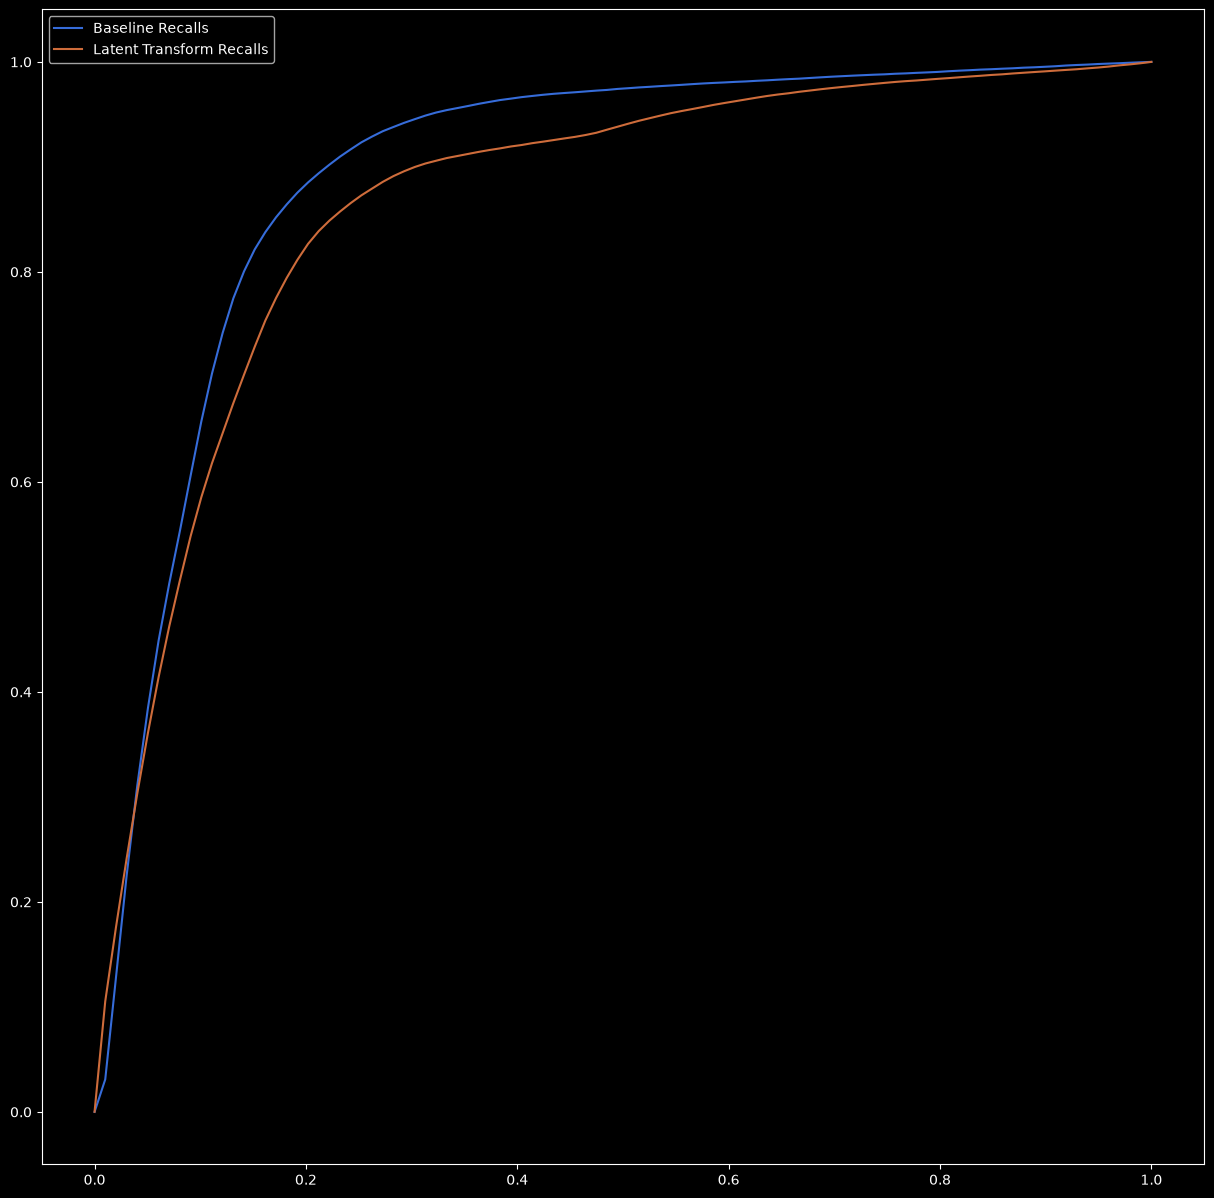

In [30]:
plt.figure(figsize=(15, 15))


plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0),
         label="Baseline Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(latent_transform_recalls).mean(axis=0),
         label="Latent Transform Recalls")


plt.legend()

In [35]:
sae_experiments: list[list] = load_experiment_metrics(latent_transform_path)

In [36]:
sae_s = []

for experiment in sae_experiments:
    sae_s += [metric.prediction for metric in experiment]

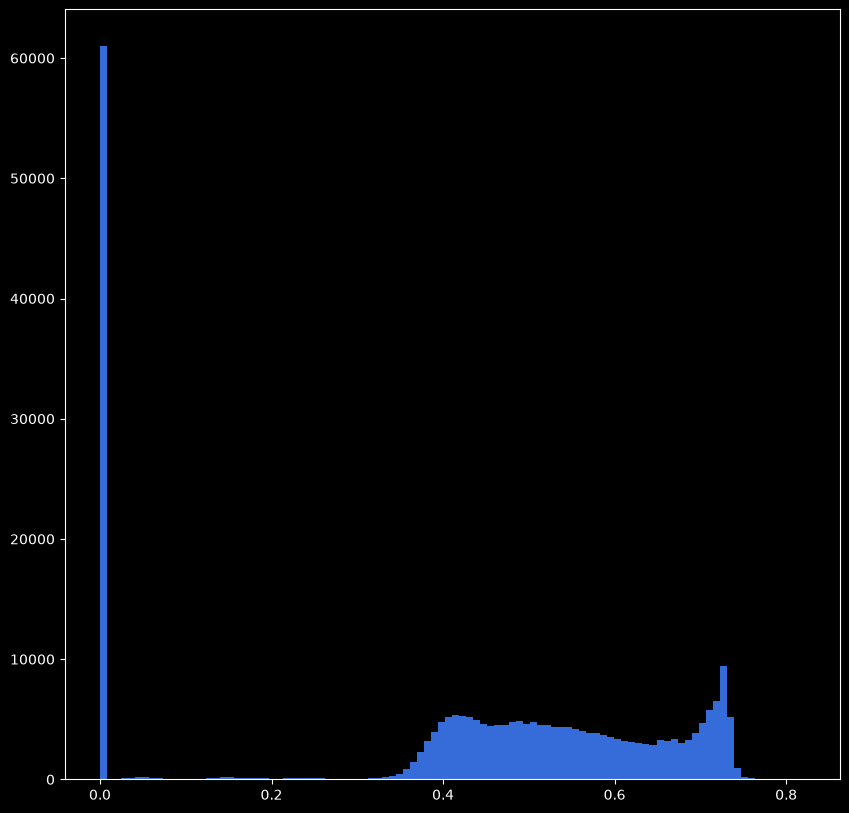

In [37]:
plt.figure(figsize=(10, 10))

plt.hist(sae_s, bins=100)
plt.show()